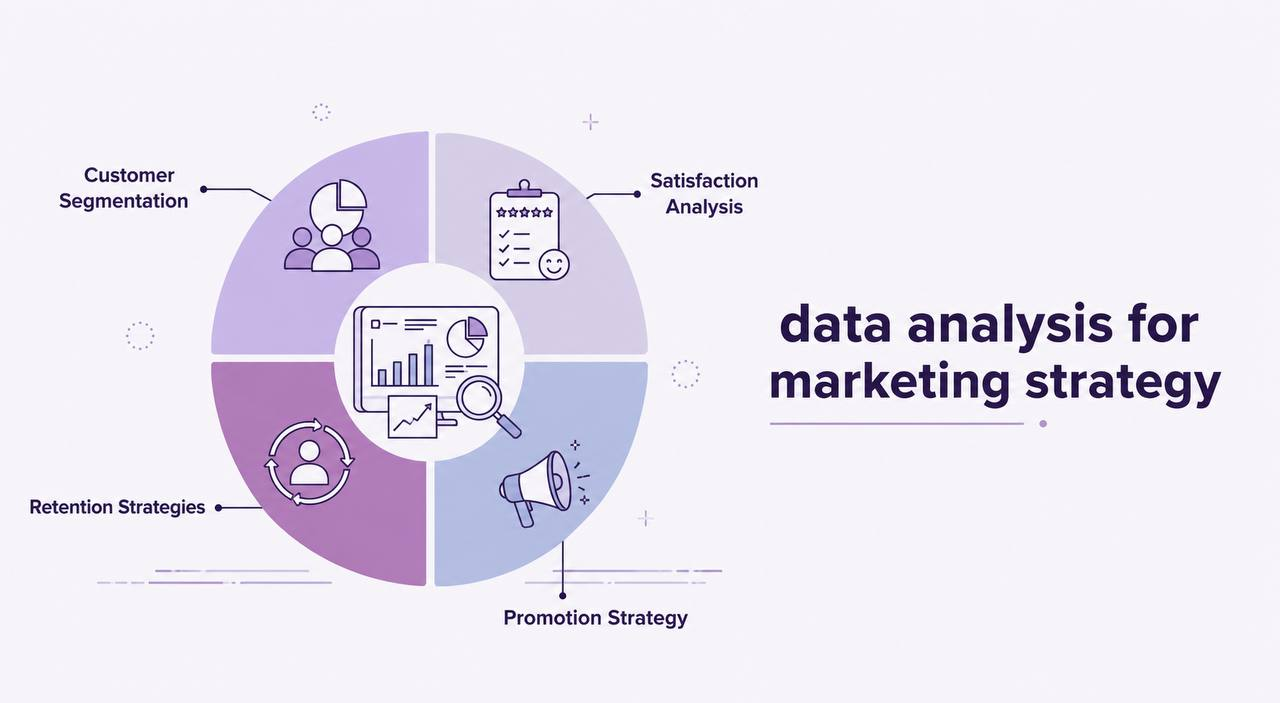

▶ <font color="light blue" size="4">Use Cases:</font>

 <font color="" size="2">**Customer Segmentation**: Analyze and categorize customers based on demographics, spending habits, and satisfaction levels.</font>

 <font color="" size="2">**Satisfaction Analysis**: Investigate factors influencing customer satisfaction and identify areas for improvement.</font>

 <font color="" size="2">**Promotion Strategy**: Assess the impact of discounts on customer spending and tailor promotional strategies accordingly.</font>

 <font color="" size="2">**Retention Strategies**: Develop targeted retention strategies by understanding the time gap since the last purchase</font>


 <font color="" size="2">Note: This dataset is synthetically generated for illustrative purposes, and any resemblance to real individuals or scenarios is coincidental.</font>

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv("/content/E-commerce Customer Behavior - Sheet1-selected-columns.csv")
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55


## 2. Data Cleaning and Preprocessing

In [ ]:
df.shape

(350, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
dtypes: bool(1), float64(2), int64(4), object(3)
memory usage: 25.1+ KB


In [ ]:
# How many rows in each column have missing values?

df.isnull().sum()


,0
Customer ID,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0


There are no null value

In [ ]:
# Check the total number of duplicate rows in the dataset

df.duplicated().sum()

np.int64(0)

There are no Duplicated Value


#  data is <font color="green" size="6">clean</font> ✅

In [ ]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


when discribe the data we found not outlier in Age and Average Rating in min , max and mean

## 3. Analysis and Visualization

### 3.1 Customer Segmentation

In [ ]:
# This section performs customer segmentation using the K-Means algorithm.
# It selects relevant features, scales them, applies clustering, and then analyzes the characteristics of each cluster.

#  Select appropriate columns for Segmentation
features = ["Age", "Total Spend", "Days Since Last Purchase"]
X = df[features]

# Scale the features as the values are quite spread out (e.g., days vs. amounts)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

#  Apply K-Means algorithm to segment customers into 3 groups (clusters)
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("    Customer Segmentation Results   ")
print(df[["Customer ID", "Age", "Total Spend", "Days Since Last Purchase", "Cluster"]])

# 5. Understand the characteristics of each group (segment) by calculating their means
print("\n    Cluster Averages for Marketing Team    ")
analysis = (
    df.groupby("Cluster")[["Age", "Total Spend", "Days Since Last Purchase"]]
    .mean()
    .round(1)
)
print(analysis)


    Customer Segmentation Results   
     Customer ID  Age  Total Spend  Days Since Last Purchase  Cluster
0            101   29      1120.20                        25        1
1            102   34       780.50                        18        0
2            103   43       510.75                        42        0
3            104   30      1480.30                        12        1
4            105   27       720.40                        55        2
..           ...  ...          ...                       ...      ...
345          446   32       660.30                        42        2
346          447   36       470.50                        27        0
347          448   30      1190.80                        28        1
348          449   34       780.20                        21        0
349          450   43       515.75                        49        0

[350 rows x 5 columns]

    Cluster Averages for Marketing Team    
          Age  Total Spend  Days Since Last Purchase
C

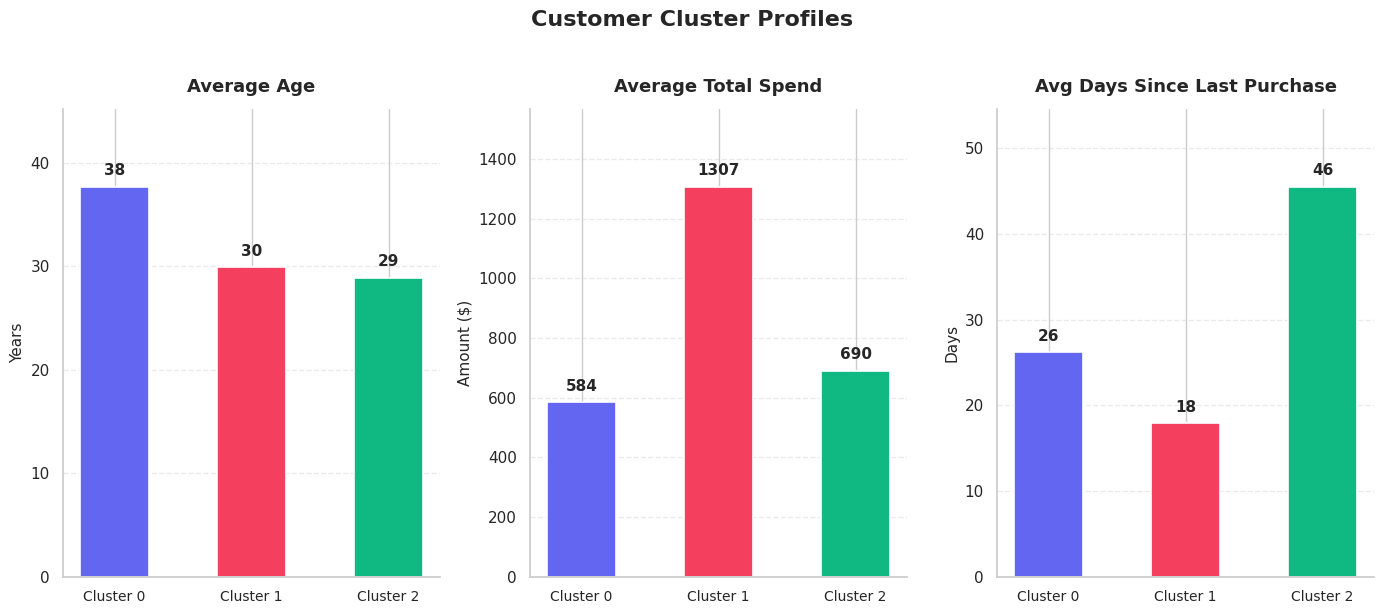

In [ ]:
# This code visualizes the average characteristics of customer clusters using bar plots.
# It generates three separate bar plots, one for 'Age', 'Total Spend', and 'Days Since Last Purchase',
# allowing for a clear comparison of these features across the identified customer segments.

features = ["Age", "Total Spend", "Days Since Last Purchase"]
colors = ['#6366f1', '#f43f5e', '#10b981']
titles = ["Average Age", "Average Total Spend", "Avg Days Since Last Purchase"]
ylabels = ["Years", "Amount ($)", "Days"]

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle("Customer Cluster Profiles", fontsize=16, fontweight='bold', y=1.02)

for idx, (feature, title, ylabel) in enumerate(zip(features, titles, ylabels)):
    ax = axes[idx]
    vals = [analysis.loc[i, feature] for i in range(3)]
    bars = ax.bar(
        ['Cluster 0', 'Cluster 1', 'Cluster 2'],
        vals,
        color=colors,
        edgecolor='white',
        linewidth=1.2,
        width=0.5
    )
    ax.bar_label(bars, fmt='%.0f', padding=6, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(0, max(vals) * 1.2)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig("cluster_profiles.png", dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Satisfaction Analysis

In [ ]:
# This section defines a function to classify customer satisfaction based on their average rating.
# It then applies this function to the DataFrame to create a new 'Satisfaction_Status' column,
# and displays an overview of customer satisfaction.


def assess_satisfaction(rating):
    if rating >= 4.0:
        return "High Satisfaction"
    elif rating >= 3.0:
        return "Neutral"
    else:
        return "Low Satisfaction"

df["Satisfaction_Status"] = df["Average Rating"].apply(assess_satisfaction)

print("--- 1. Overview of Customer Satisfaction Status in Your File ---")
print(df[["Customer ID", "Average Rating", "Satisfaction_Status"]])

--- 1. Overview of Customer Satisfaction Status in Your File ---
     Customer ID  Average Rating Satisfaction_Status
0            101             4.6   High Satisfaction
1            102             4.1   High Satisfaction
2            103             3.4             Neutral
3            104             4.7   High Satisfaction
4            105             4.0   High Satisfaction
..           ...             ...                 ...
345          446             3.8             Neutral
346          447             3.0             Neutral
347          448             4.5   High Satisfaction
348          449             4.2   High Satisfaction
349          450             3.3             Neutral

[350 rows x 3 columns]


In [ ]:
# Linking satisfaction to Membership Type
# To understand which membership categories might be experiencing issues

membership_analysis = (
    df.groupby("Membership Type")["Average Rating"].mean().round(2)
)

print("\n   2. Average Rating by Membership Type   ")
print(membership_analysis)


   2. Average Rating by Membership Type   
Membership Type
Bronze    3.32
Gold      4.68
Silver    4.05
Name: Average Rating, dtype: float64


In [ ]:
# Linking satisfaction to Cities
city_analysis = df.groupby("City")["Average Rating"].mean().round(2)

print("\n   3. Average Rating by Cities   ")
print(city_analysis)


   3. Average Rating by Cities   
City
Chicago          3.46
Houston          3.19
Los Angeles      4.17
Miami            3.93
New York         4.54
San Francisco    4.81
Name: Average Rating, dtype: float64


### 3.3 Promotion Strategy

In [ ]:
#  Calculate average spend and number of items based on discount presence
promo_analysis = (
    df.groupby("Discount Applied")[["Total Spend", "Items Purchased"]]
    .mean()
    .round(1)
)

print("    1. Promotional Performance Comparison Table  ")
print(promo_analysis)

print("\n    2. Automated Strategic Recommendation for Management  ")

# Make a data-driven decision
spend_with_discount = promo_analysis.loc[True, "Total Spend"]
spend_without_discount = promo_analysis.loc[False, "Total Spend"]

if spend_with_discount > (spend_without_discount * 1.5):
    print(
        "Discounts are successful! Customers spend double when a discount is present."
    )
    print(
        "Strategy: Continue promotional offers, but target them specifically towards high-profit margin items to protect your profits."
    )
else:
    print(
        "Discounts are not effective! The difference in spending is minimal compared to the loss in margin."
    )


    1. Promotional Performance Comparison Table  
                  Total Spend  Items Purchased
Discount Applied                              
False                   903.5             13.1
True                    787.3             12.1

    2. Automated Strategic Recommendation for Management  
Discounts are not effective! The difference in spending is minimal compared to the loss in margin.
Strategy: Immediately stop general discounts, and replace them with a 'buy two get one free' strategy to increase the number of items sold without reducing product value.


### 3.4 Retention Strategies

In [ ]:
# This code defines a function `retention_strategy` to classify customers into different risk levels
# based on their 'Days Since Last Purchase' and suggests corresponding retention actions.
# It then applies this strategy to the DataFrame and prints a summary of customer retention.
def retention_strategy(days):
    if days <= 15:
        return (
            "Safe",
            "Customer is active; don't bombard them with ads, let their experience be natural.",
        )
    elif days <= 45:
        return (
            "Churn Risk",
            "Starting to drift away; send them an email with new products they might be interested in based on their recent activities.",
        )
    else:
        return (
            "Critical",
            "Customer has completely churned! Send them an SMS with a very strong discount code (e.g., 'We miss you, here's 25% off') to bring them back immediately.",
        )


# Apply the function to the data
df[["Risk Level", "Retention Action"]] = df[
    "Days Since Last Purchase"
].apply(lambda x: pd.Series(retention_strategy(x)))

print("--- Customer Retention Management Table and Absence Periods ---")
print(
    df[
        [
            "Customer ID",
            "Days Since Last Purchase",
            "Risk Level",
            "Retention Action",
        ]
    ]
)

--- Customer Retention Management Table and Absence Periods ---
     Customer ID  Days Since Last Purchase  Risk Level  \
0            101                        25  Churn Risk   
1            102                        18  Churn Risk   
2            103                        42  Churn Risk   
3            104                        12        Safe   
4            105                        55    Critical   
..           ...                       ...         ...   
345          446                        42  Churn Risk   
346          447                        27  Churn Risk   
347          448                        28  Churn Risk   
348          449                        21  Churn Risk   
349          450                        49    Critical   

                                      Retention Action  
0    Starting to drift away; send them an email wit...  
1    Starting to drift away; send them an email wit...  
2    Starting to drift away; send them an email wit...  
3    Custom